In [1]:
import math
from datetime import timedelta
from operator import attrgetter

import matplotlib.pyplot as plt
import numpy as np
import trajan as ta
import xarray as xr
import pandas as pd
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

import parcels
from xhistogram.xarray import histogram as xhist
from parcels import StatusCode

/home/b/b384140/.conda/envs/parcels/lib/python3.14/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
ds = xr.open_dataset('/work/bk1450/b384140/CV_gridParticles.zarr').compute()
ds = ds.isel(obs=slice(1, None))
ds

<xarray.Dataset> Size: 144MB
Dimensions:     (trajectory: 30000, obs: 239)
Coordinates:
  * trajectory  (trajectory) int64 240kB 0 1 2 3 4 ... 29996 29997 29998 29999
  * obs         (obs) int32 956B 1 2 3 4 5 6 7 8 ... 233 234 235 236 237 238 239
Data variables:
    lat         (trajectory, obs) float32 29MB 16.7 16.71 16.71 ... 17.47 17.48
    lon         (trajectory, obs) float32 29MB -25.16 -25.16 ... -25.61 -25.61
    time        (trajectory, obs) datetime64[ns] 57MB 2025-08-01T01:00:00 ......
    z           (trajectory, obs) float32 29MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes:
    Conventions:            CF-1.6/CF-1.7
    feature_type:           trajectory
    ncei_template_version:  NCEI_NetCDF_Trajectory_Template_v2.0
    parcels_kernels:        JITParticleAdvectionRK4CheckOutOfBounds
    parcels_mesh:           spherical
    parcels_version:        3.1.4

In [3]:
lon_bins = np.linspace(ds.lon.min().data[()], ds.lon.max().data[()], 21)
lat_bins = np.linspace(ds.lat.min().data[()], ds.lat.max().data[()], 21)

In [4]:
obs_counts = xhist(
    ds.lon, ds.lat,
    bins=[lon_bins, lat_bins],
    dim=["trajectory", ],
    bin_dim_suffix=""
)

obs_counts

<xarray.DataArray 'histogram_lon_lat' (obs: 239, lon: 20, lat: 20)> Size: 765kB
array([[[   0,    0,    0, ...,    0,    0,    0],
        [   0,    0,    0, ...,    0,    0,    0],
        [   0,    0,    0, ...,    0,    0,    0],
        ...,
        [1032, 1228, 1246, ...,    0,    0,    0],
        [1031, 1238, 1287, ...,    0,    0,    0],
        [ 564,  715,  766, ...,    0,    0,    0]],

       [[   0,    0,    0, ...,    0,    0,    0],
        [   0,    0,    0, ...,    0,    0,    0],
        [   0,    0,    0, ...,    0,    0,    0],
        ...,
        [1024, 1240, 1200, ...,    0,    0,    0],
        [1046, 1233, 1323, ...,    0,    0,    0],
        [ 503,  660,  770, ...,    0,    0,    0]],

       [[   0,    0,    0, ...,    0,    0,    0],
        [   0,    0,    0, ...,    0,    0,    0],
        [   0,    0,    0, ...,    0,    0,    0],
        ...,
...
        ...,
        [   0,   10,    2, ...,    0,    0,    0],
        [   0,    0,    8, ...,    0,    0,    0],
        [   0,    0,    0, ...,    0,    0,    0]],

       [[   0,    0,    0, ...,    0,    0,  168],
        [   0,    0,    0, ...,    0,    0,  166],
        [   0,    0,    0, ...,    0,    0,  170],
        ...,
        [   0,    8,    4, ...,    0,    0,    0],
        [   0,    0,    8, ...,    0,    0,    0],
        [   0,    0,    0, ...,    0,    0,    0]],

       [[   0,    0,    0, ...,    0,    0,  169],
        [   0,    0,    0, ...,    0,    0,  167],
        [   0,    0,    0, ...,    0,    0,  173],
        ...,
        [   0,    7,    5, ...,    0,    0,    0],
        [   0,    0,    8, ...,    0,    0,    0],
        [   0,    0,    0, ...,    0,    0,    0]]], shape=(239, 20, 20))
Coordinates:
  * obs      (obs) int32 956B 1 2 3 4 5 6 7 8 ... 233 234 235 236 237 238 239
  * lon      (lon) float64 160B -25.98 -25.92 -25.86 ... -24.97 -24.91 -24.85
  * lat      (lat) float64 160B 16.72 16.79 16.85 16.92 ... 17.83 17.89 17.96

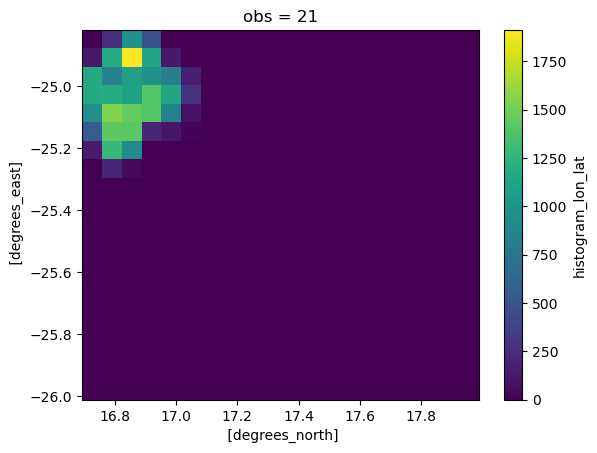

In [5]:
obs_counts.isel(obs = 20).plot()

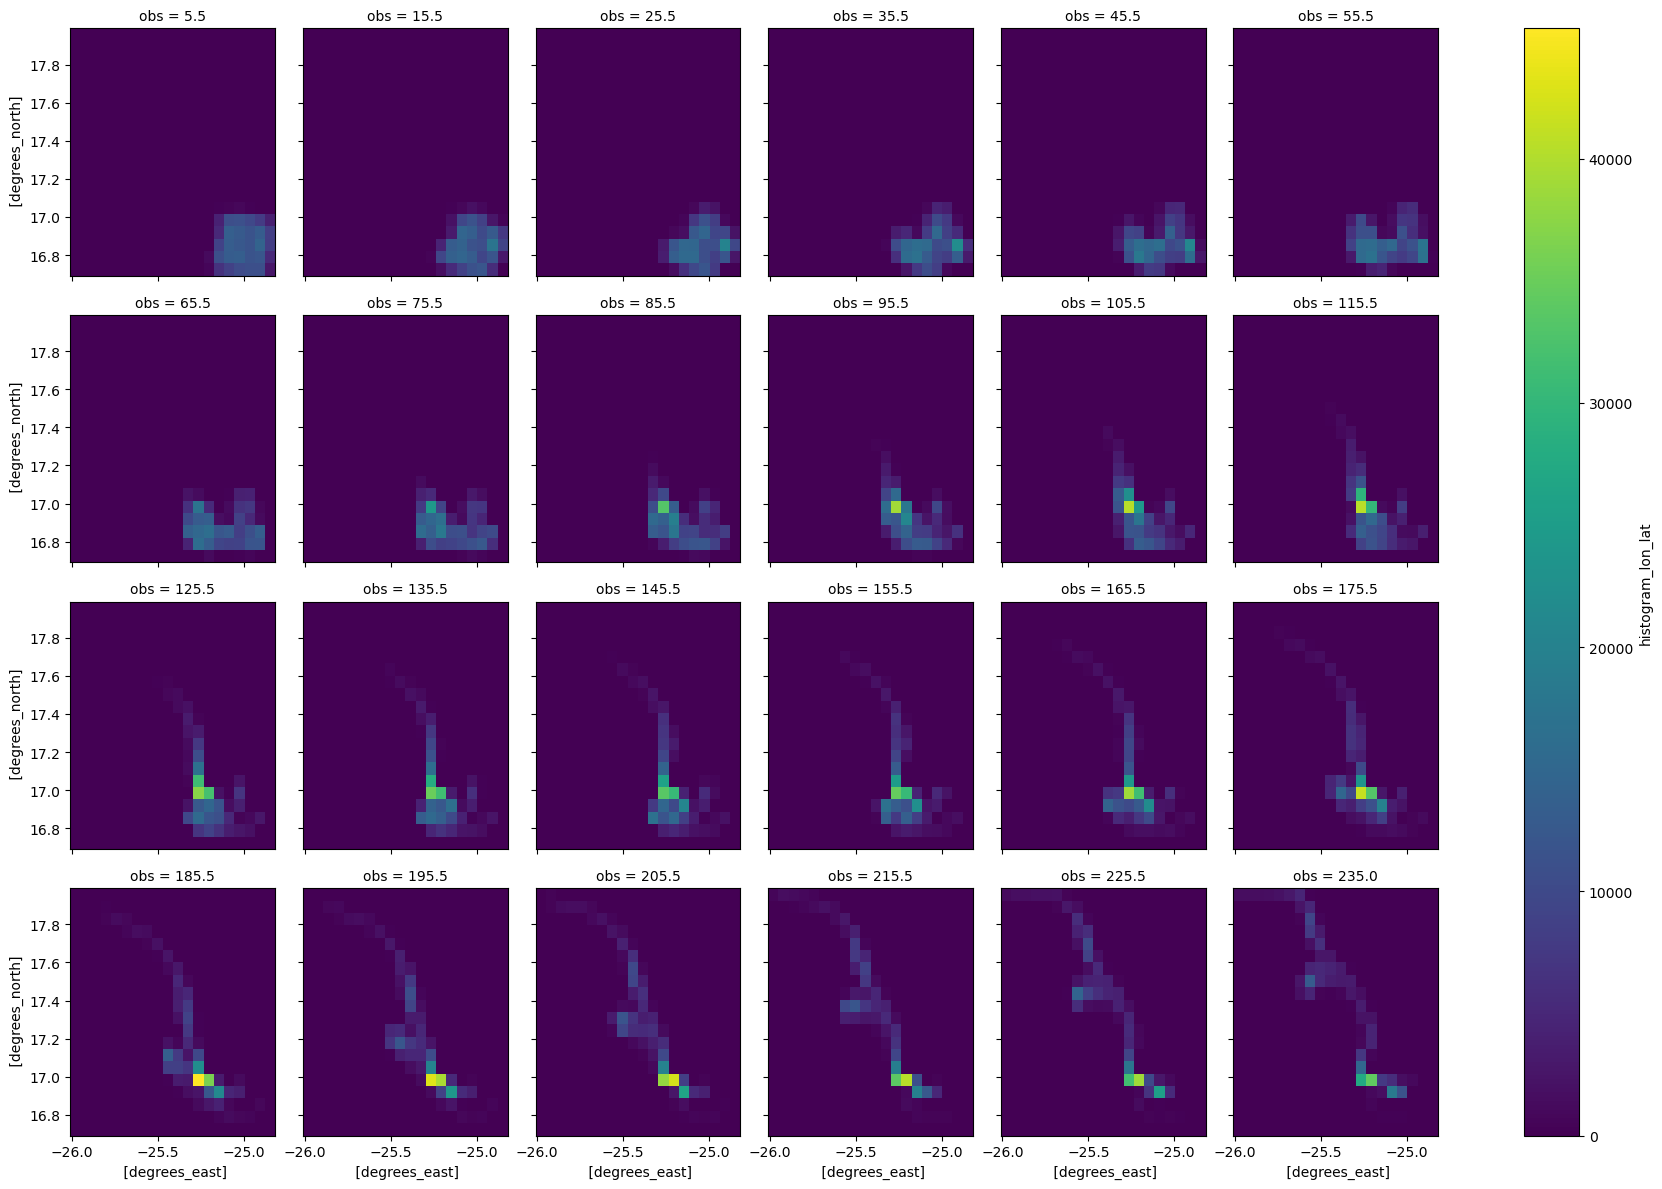

In [6]:
obs_counts.pad(obs=(0, 1), constant_values=0).coarsen(obs = 10, boundary = "trim").sum().plot(col = "obs", col_wrap = 6, x = "lon", y = "lat",  figsize=(18, 12))